# Trabalho Prático 01 - KNN Hardcore
# Daniel de Jesus Moreira
# João Guilherme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [ ]:
# Carregando a base de dados Iris direto do repositório da UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
colunas = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv(url, names=colunas)

# 1. Embaralhando os dados
df_embaralhado = df.sample(frac=1, random_state=42).reset_index(drop=True)

# 2. Definindo a porcentagem de divisão (80% para treino e 20% para teste)
tamanho_treino = int(0.8 * len(df_embaralhado))

# 3. Separando os DataFrames de treino e teste
df_treino = df_embaralhado.iloc[:tamanho_treino]
df_teste = df_embaralhado.iloc[tamanho_treino:]

# 4. Separando as características (X) dos rótulos das espécies (y) e convertendo para matrizes do Numpy
X_treino = df_treino.drop('species', axis=1).values
y_treino = df_treino['species'].values

X_teste = df_teste.drop('species', axis=1).values
y_teste = df_teste['species'].values

print(f"Total de amostras para treino: {len(X_treino)}")
print(f"Total de amostras para teste: {len(X_teste)}")

Total de amostras para treino: 120
Total de amostras para teste: 30


In [ ]:
# Função matemática para calcular a Distância Euclidiana entre dois pontos
def distancia_euclidiana(ponto1, ponto2):
    distancia = np.sqrt(np.sum((ponto1 - ponto2) ** 2))
    return distancia

As medidas da Flor A são: [6.1 2.8 4.7 1.2]
As medidas da Flor B são: [5.7 3.8 1.7 0.3]
A distância euclidiana entre elas é: 3.3121


In [ ]:
# 1. Função para prever a classe de UMA única flor
def prever_classificacao(X_treino, y_treino, amostra_teste, k):
    distancias = []
    
    # Calcula a distância da amostra para todas as flores de treino
    for i in range(len(X_treino)):
        dist = distancia_euclidiana(amostra_teste, X_treino[i])
        # Guarda uma tupla com a distância e a espécie daquela flor
        distancias.append((dist, y_treino[i]))
        
    # Ordena a lista de distâncias da menor para a maior
    distancias.sort(key=lambda x: x[0])
    
    # Pega apenas os 'k' primeiros vizinhos (os mais próximos)
    vizinhos_proximos = distancias[:k]
    
    # Extrai só os nomes das espécies desses vizinhos
    especies_vizinhos = [vizinho[1] for vizinho in vizinhos_proximos]
    
    # Votação: o Counter conta quem aparece mais. 
    # most_common(1) retorna uma lista com o mais comum, ex: [('Iris-setosa', 3)]
    votos = Counter(especies_vizinhos)
    especie_vencedora = votos.most_common(1)[0][0]
    
    return especie_vencedora

# 2. Função para rodar a previsão para TODAS as flores do conjunto de teste
def knn_hardcore(X_treino, y_treino, X_teste, k):
    previsoes = []
    for amostra in X_teste:
        previsao = prever_classificacao(X_treino, y_treino, amostra, k)
        previsoes.append(previsao)
    return previsoes

Cérebro do KNN Hardcore criado com sucesso!


In [5]:
# Valores de k exigidos pelo trabalho
valores_k = [1, 3, 5, 7]

print("--- Taxa de Reconhecimento (Acurácia) do KNN Hardcore ---")

# Vamos guardar as previsões do melhor 'k' para usarmos na matriz de confusão depois
melhor_k = 0
melhor_acuracia = 0
melhores_previsoes = []

for k in valores_k:
    # 1. Fazendo as previsões para as 30 flores de teste
    previsoes = knn_hardcore(X_treino, y_treino, X_teste, k)
    
    # 2. Contando quantos acertos o modelo teve
    acertos = 0
    for i in range(len(y_teste)):
        if previsoes[i] == y_teste[i]:
            acertos += 1
            
    # 3. Calculando a acurácia (Acertos / Total de Testes)
    acuracia = acertos / len(y_teste)
    
    # Salvando o melhor resultado para a próxima etapa
    if acuracia > melhor_acuracia:
        melhor_acuracia = acuracia
        melhor_k = k
        melhores_previsoes = previsoes
    
    print(f"Para k = {k}:")
    print(f"  Acertos: {acertos} de {len(y_teste)}")
    print(f"  Acurácia: {acuracia * 100:.2f}%\n")

print(f"O melhor valor de k foi {melhor_k} com {melhor_acuracia * 100:.2f}% de acerto.")

--- Taxa de Reconhecimento (Acurácia) do KNN Hardcore ---
Para k = 1:
  Acertos: 29 de 30
  Acurácia: 96.67%

Para k = 3:
  Acertos: 29 de 30
  Acurácia: 96.67%

Para k = 5:
  Acertos: 29 de 30
  Acurácia: 96.67%

Para k = 7:
  Acertos: 29 de 30
  Acurácia: 96.67%

O melhor valor de k foi 1 com 96.67% de acerto.


--- Métricas de Avaliação para o KNN Hardcore (k=1) ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         7
Iris-versicolor       0.92      1.00      0.96        11
 Iris-virginica       1.00      0.92      0.96        12

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



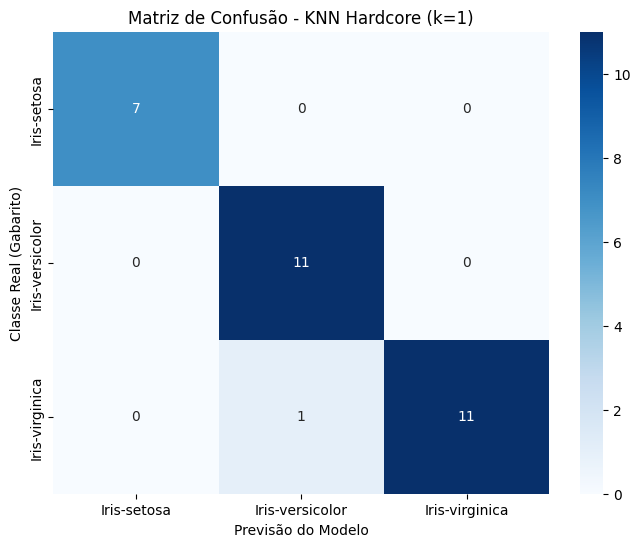

In [6]:
from sklearn.metrics import confusion_matrix, classification_report

print(f"--- Métricas de Avaliação para o KNN Hardcore (k={melhor_k}) ---")

relatorio = classification_report(y_teste, melhores_previsoes)
print(relatorio)

matriz_confusao = confusion_matrix(y_teste, melhores_previsoes)

plt.figure(figsize=(8, 6))
classes_unicas = np.unique(y_teste)
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', xticklabels=classes_unicas, yticklabels=classes_unicas)
plt.title(f'Matriz de Confusão - KNN Hardcore (k={melhor_k})')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Classe Real (Gabarito)')
plt.show()